In [77]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cmocean.cm as cm
import shapely.geometry
from matplotlib.patches import Polygon as MatplotlibPolygon
import geopandas as gpd
# from scipy.optimize import curve_fit
# from scipy import signal
import matplotlib.patches as patches

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

from salishsea_tools import viz_tools

# Goal
Turn model results for 2019 into something that shows the spatial and temporal distributions of scrubber washwater in the Salish Sea. We were going to do 3 dyes with different half-lives, so I will probably have this notebook as the master notebook and then make two others for the different dyes.

Our parameter of interest is washwater concentration. We can use the concentrations reported in Hermansson et al. and the initial report (cite) to set contours of washwater concentration.

In [78]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = 1 - mesh.tmask[0]
volume = ((1-tmask) * mesh.e3t_0[0] * mesh.e1t[0] * mesh.e2t[0]).rename({'z':'depth'})

In [79]:
## read in the input washwater file
ww_in = xr.open_dataset('/ocean/cdonaldson/scrubbers/yearly_obs/scrubber_1d_obs_tempsalcalc_20190101_20191231.nc')

## read in the physics file
phys = xr.open_dataset('/data/sallen/results/MEOPAR/Scrubberwater/01jan22/SalishSea_1d_20220101_20220630_grid_T.nc')

In [80]:
## read in the year of results
ww_out = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20220101_20221231_scrb_T.nc')

## read in the averaged results
ww_seas_mean = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20220101_20221231_scrb_T_seas.nc')
ww_mon_mean = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20220101_20221231_scrb_T_mon.nc')

## read in the timeseries of accumulation of results
ww_accumulated = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20190101_20221231_scrb_T_didx8_accumulation.nc')

## Concentrations of Interest

- Fertilisation of sea urchin eggs impacted @ 1: 1,000,000 (Environmental Impacts... Jalken et al., 2024)
- Early development of polycheats, mussels, and crustaceans impacted @ 1: 100,000 (Environmental Impacts... Jalken et al., 2024)
- HC5 = 0.0003% (Impact Assessment... Hermansson et al., 2025)
- HC5 lower limit = 0.00001% (Impact Assessment... Hermansson et al., 2025)
- HC5 upper limit = 0.009% (Impact Assessment... Hermansson et al., 2025)
- (HC50 = 0.6%; lower limit = 0.02%, upper limit = 1.4%) (Impact Assessment... Hermansson et al., 2025)

In [81]:
custom_colors = ['#ff595e', '#ffca3a', '#8ac926', '#1982c4', '#6a4c93']
# custom_colors = ['#E0E0E2', '#ff595e', '#ffca3a', '#8ac926', '#1982c4', '#6a4c93']

In [82]:
impact_urchins = 1/1000000
impact_devel = 1/100000
HC5 = 0.0003/100
HC5_low = 0.00001/100
HC5_high = 0.009/100
HC50_low = 0.02/100
HC50 = 0.6/100
HC50_high = 1.4/100

In [83]:
lim_dict = {
    'impact_urchins': impact_urchins,
    'impact_devel': impact_devel,
    'HC5': HC5,
    'HC5_low': HC5_low,
    'HC5_high': HC5_high,
    'HC50_low': HC50_low,
    'HC50': HC50,
    'HC50_high': HC50_high
}

lim_dict = {k: v for k, v in sorted(lim_dict.items(), key=lambda item: item[1])}
lim_dict

{'HC5_low': 1.0000000000000001e-07,
 'impact_urchins': 1e-06,
 'HC5': 2.9999999999999997e-06,
 'impact_devel': 1e-05,
 'HC5_high': 8.999999999999999e-05,
 'HC50_low': 0.0002,
 'HC50': 0.006,
 'HC50_high': 0.013999999999999999}

## Visualize: Concentration Plots

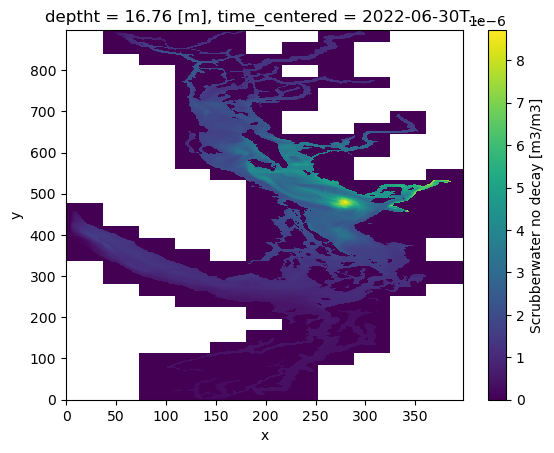

In [84]:
conc = ww_out.no_decay.isel(deptht=16, time_counter=180)
conc.plot()

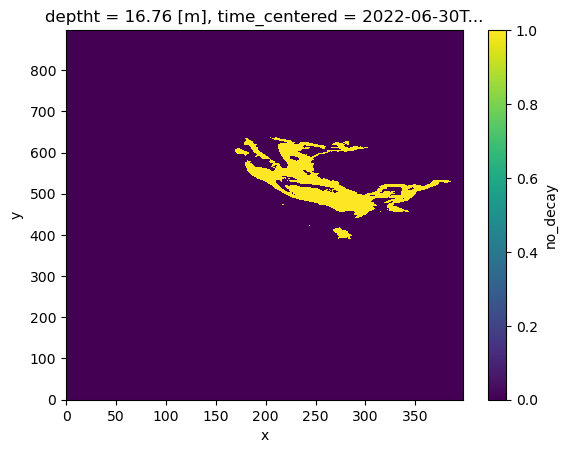

In [85]:
## concentration of concern is 0.0003%
bool = conc >= HC5
bool.plot()

In [86]:
## depthwise sum of the whole domain, might need to do in a different notebook. save this output then read it back in

In [87]:
## turn the whole domain into concentrations, might need to do this in a different notebook. save this output and read it back in

In [88]:
## split into average concentration by layer slices. maybe 0-10m, 10-20m, 20-30m, 

### Functions

In [89]:
def plot_conc_seasonal(dep_idx, season, axs, variable, cbar):
    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ({}) '.format(variable) + r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, season))
    viz_tools.set_aspect(axs);
    axs.legend()

In [90]:
def plot_conc_monthly(dep_idx, season, axs, variable, cbar, legend):
    washwater = np.ma.masked_array(ww_mon_mean.isel(month=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ({}) '.format(variable) + r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nMon idx = {}'.format(dep_idx, season))
    viz_tools.set_aspect(axs);
    if legend == True:
        axs.legend()

In [91]:
def plot_bool_seasonal(dep_idx, season, axs, variable, limit, cbar):
    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    bool = washwater >= HC5
    colours = axs.pcolormesh(bool, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=r'({}) washwater >= {:.2g}'.format(variable, limit, 2), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, season))
    viz_tools.set_aspect(axs);
    axs.legend()

In [92]:
def plot_conc_daily(dep_idx, time_idx, axs, variable, cbar):
    washwater = np.ma.masked_array(ww_out.isel(time_counter=time_idx).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ({}) '.format(variable) + r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, time_idx))
    viz_tools.set_aspect(axs);
    axs.legend()

In [93]:
def plot_bool_daily(dep_idx, time_idx, axs, variable, limit, cbar):
    washwater = np.ma.masked_array(ww_out.isel(time_counter=time_idx).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    bool = washwater >= HC5
    colours = axs.pcolormesh(bool, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=r'({}) washwater >= {:.2g}'.format(variable, limit, 2), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, time_idx))
    viz_tools.set_aspect(axs);
    axs.legend()

### Plots

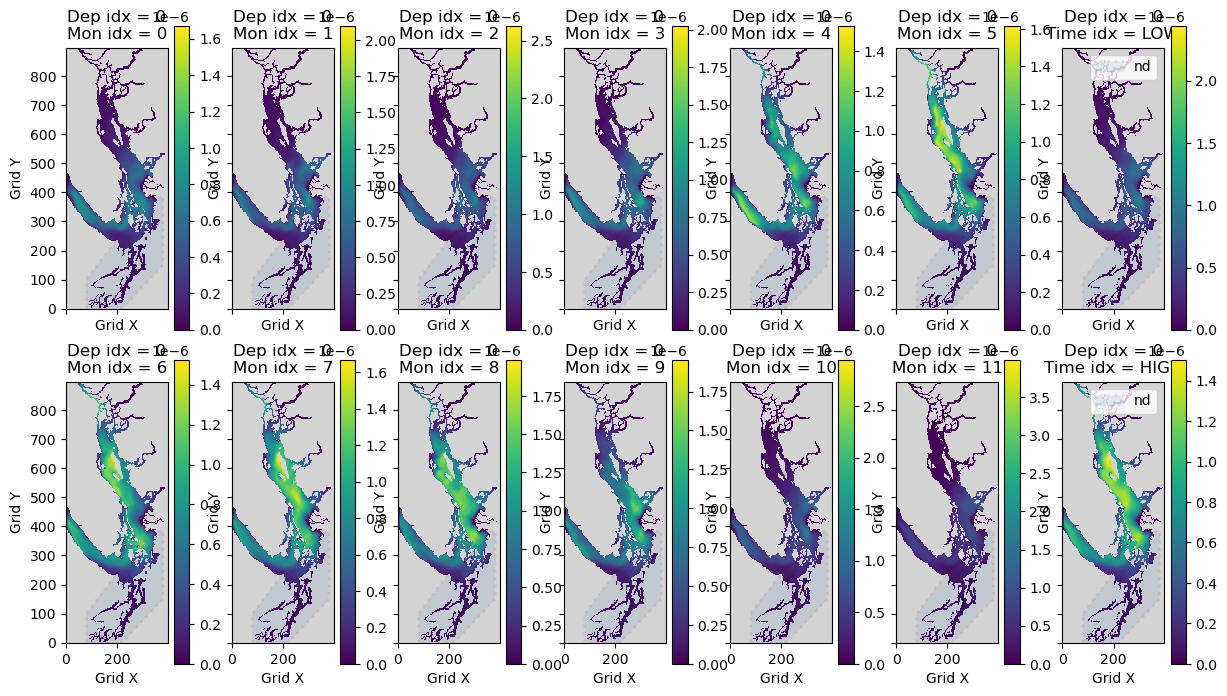

In [94]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(2,7, figsize = (12, 7), sharey=True, sharex=True)
fig.tight_layout(pad=1.2)

plot_conc_monthly(0, 0, ax1[0,0], 'slow_decay', False, False)
plot_conc_monthly(0, 1, ax1[0,1], 'slow_decay', False, False)
plot_conc_monthly(0, 2, ax1[0,2], 'slow_decay', False, False)
plot_conc_monthly(0, 3, ax1[0,3], 'slow_decay', False, False)
plot_conc_monthly(0, 4, ax1[0,4], 'slow_decay', False, False)
plot_conc_monthly(0, 5, ax1[0,5], 'slow_decay', False, False)
plot_conc_seasonal(0, 'LOW', ax1[0,6], 'slow_decay', False)

plot_conc_monthly(0, 6, ax1[1,0], 'slow_decay', False, False)
plot_conc_monthly(0, 7, ax1[1,1], 'slow_decay', False, False)
plot_conc_monthly(0, 8, ax1[1,2], 'slow_decay', False, False)
plot_conc_monthly(0, 9, ax1[1,3], 'slow_decay', False, False)
plot_conc_monthly(0, 10, ax1[1,4], 'slow_decay', False, False)
plot_conc_monthly(0, 11, ax1[1,5], 'slow_decay', False, False)
plot_conc_seasonal(0, 'HIGH', ax1[1,6], 'slow_decay', False)

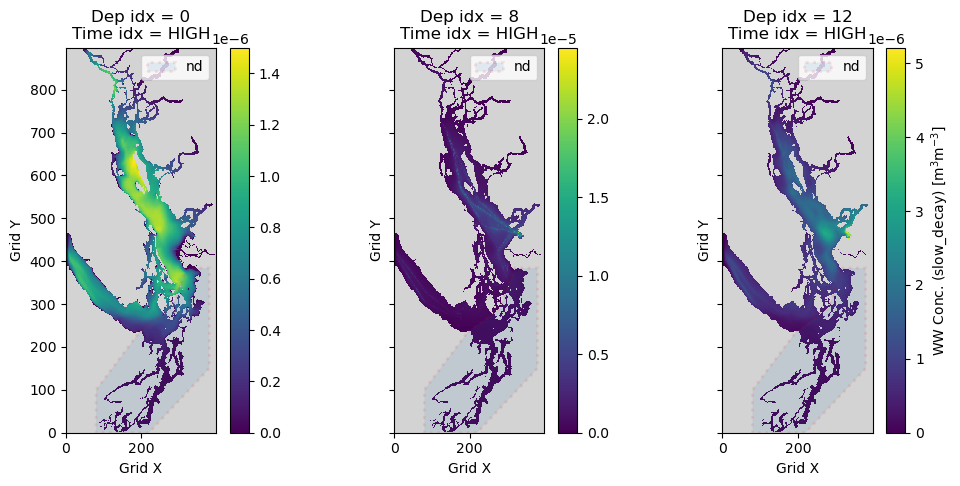

In [95]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,3, figsize = (12, 5), sharey=True)
seas = 'HIGH'

plot_conc_seasonal(0, seas, ax1[0], 'slow_decay', False)
plot_conc_seasonal(8, seas, ax1[1], 'slow_decay', False)
plot_conc_seasonal(12, seas, ax1[2], 'slow_decay', True)

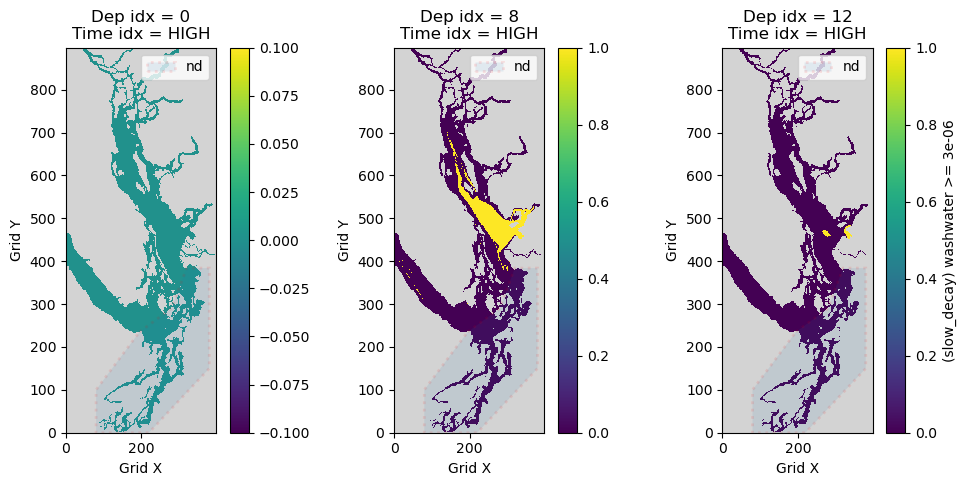

In [96]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,3, figsize = (12, 5))
seas = 'HIGH'

plot_bool_seasonal(0, seas, ax1[0], 'slow_decay', HC5, False)
plot_bool_seasonal(8, seas, ax1[1], 'slow_decay', HC5, False)
plot_bool_seasonal(12, seas, ax1[2], 'slow_decay', HC5, True)

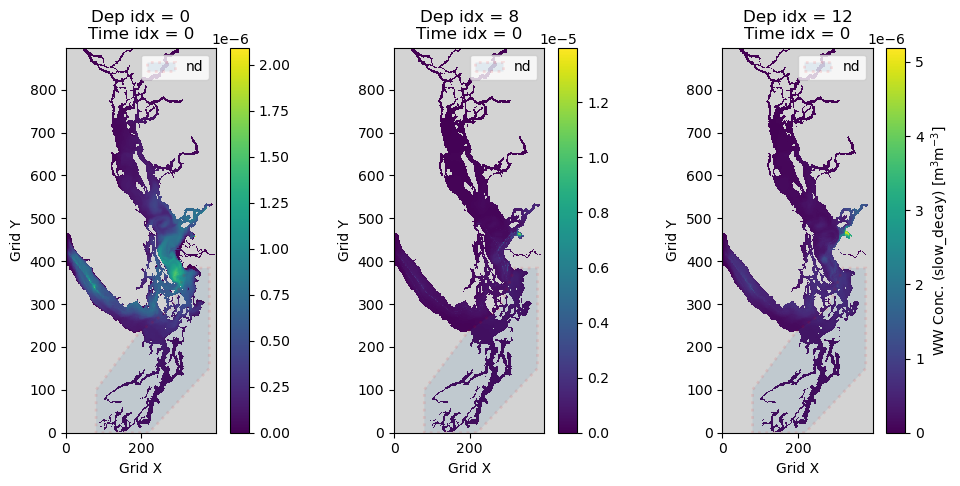

In [97]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,3, figsize = (12, 5))
time_idx = 0

plot_conc_daily(0, time_idx, ax1[0], 'slow_decay', False)
plot_conc_daily(8, time_idx, ax1[1], 'slow_decay', False)
plot_conc_daily(12, time_idx, ax1[2], 'slow_decay', True)

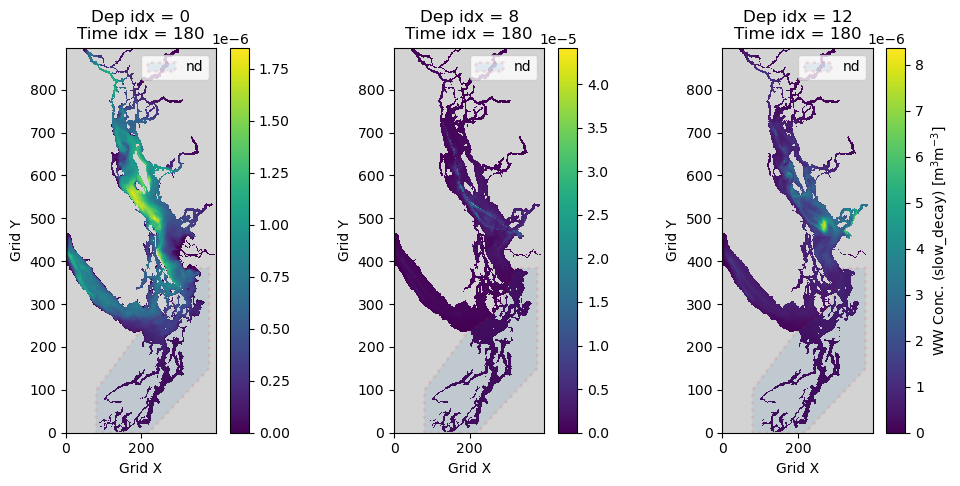

In [98]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,3, figsize = (12, 5))
time_idx = 180

plot_conc_daily(0, time_idx, ax1[0], 'slow_decay', False)
plot_conc_daily(8, time_idx, ax1[1], 'slow_decay', False)
plot_conc_daily(12, time_idx, ax1[2], 'slow_decay', True)

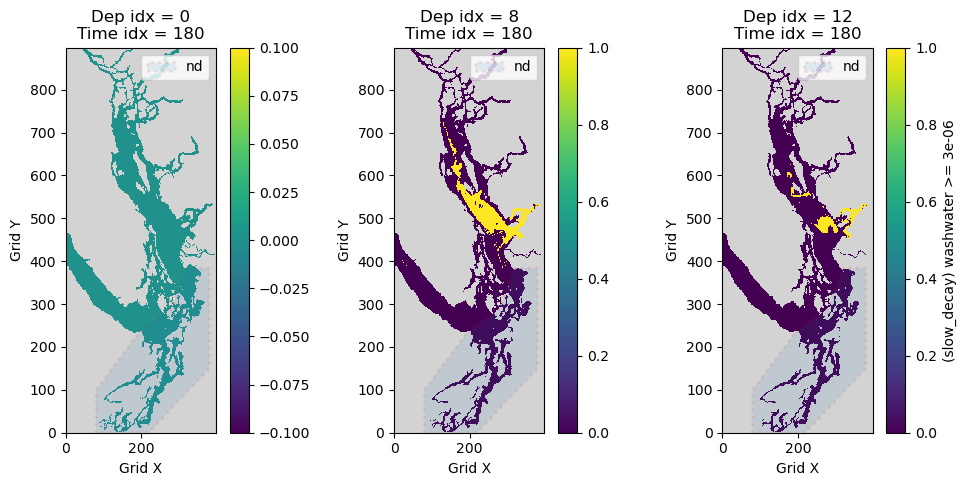

In [99]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,3, figsize = (12, 5))
time_idx = 180

plot_bool_daily(0, time_idx, ax1[0], 'slow_decay', HC5, False)
plot_bool_daily(8, time_idx, ax1[1], 'slow_decay', HC5, False)
plot_bool_daily(12, time_idx, ax1[2], 'slow_decay', HC5, True)

In [100]:
def plot_contours_seasonal(dep_idx, season, axs, variable, cbar, legend, levels):

    cmap = mcolors.ListedColormap(custom_colors)
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    maxm = np.nanmax(washwater)
    colours = axs.contourf(washwater, levels=levels, cmap=cmap, norm=norm)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ({}) '.format(variable) + r'[m$^3$m$^{-3}$]'), location='right')
    else:
        return [colours, variable]
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, season))
    viz_tools.set_aspect(axs);
    if legend == True:
        axs.legend()

    # print("Min value of washwater:", washwater.min())
    # print("Max value of washwater:", washwater.max())

In [101]:
# cmap = mpl.colormaps['viridis']
# cmap.set_bad('lightgray')
# cmap.set_under('gray')

# fig, ax1 = plt.subplots(40,2, figsize = (6, 80), sharey=True)

# for i in np.arange(40):
#     plot_contours_seasonal(i, 'HIGH', ax1[i,0], 'slow_decay', True, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
#     plot_contours_seasonal(i, 'LOW', ax1[i,1], 'slow_decay', True, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])

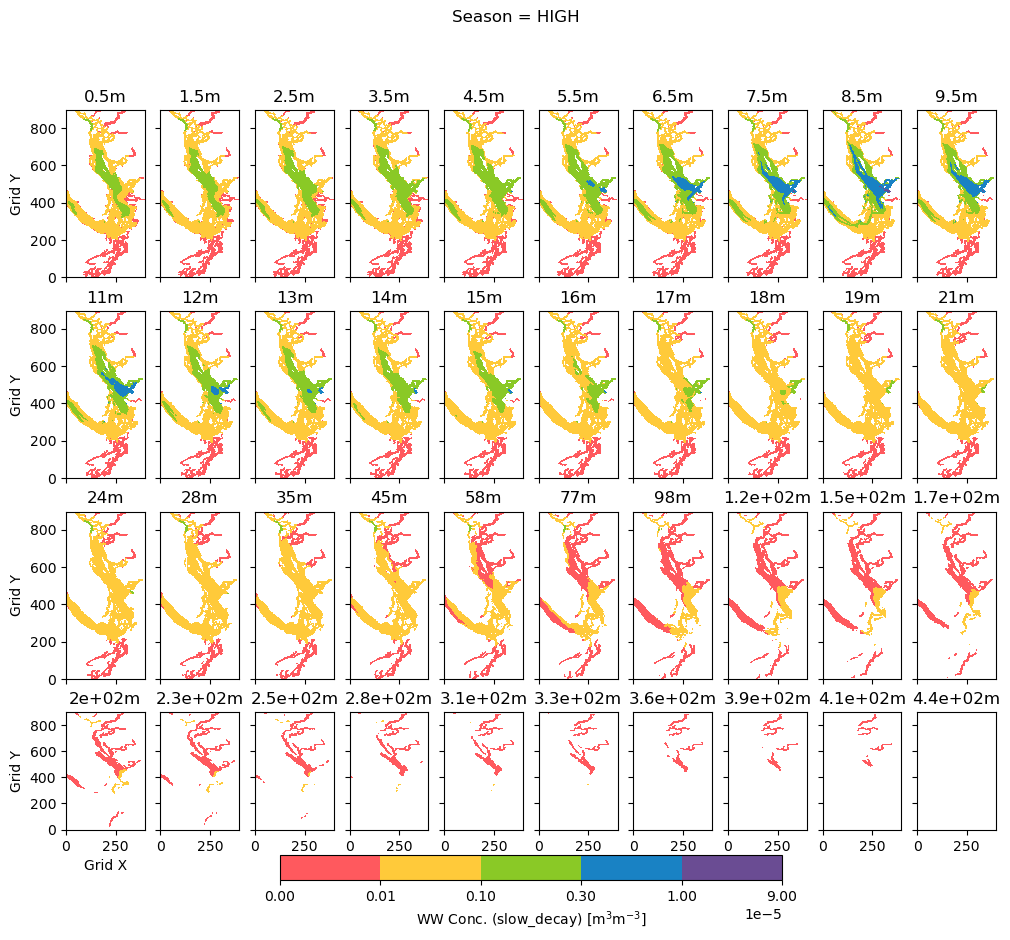

In [102]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12, 10), sharey=True, sharex=True)
fig.suptitle('Season = HIGH')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, 'HIGH', ax1[y,x], 'slow_decay', False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.2g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. ({}) '.format(vars[1]) + r'[m$^3$m$^{-3}$]'), location='bottom')

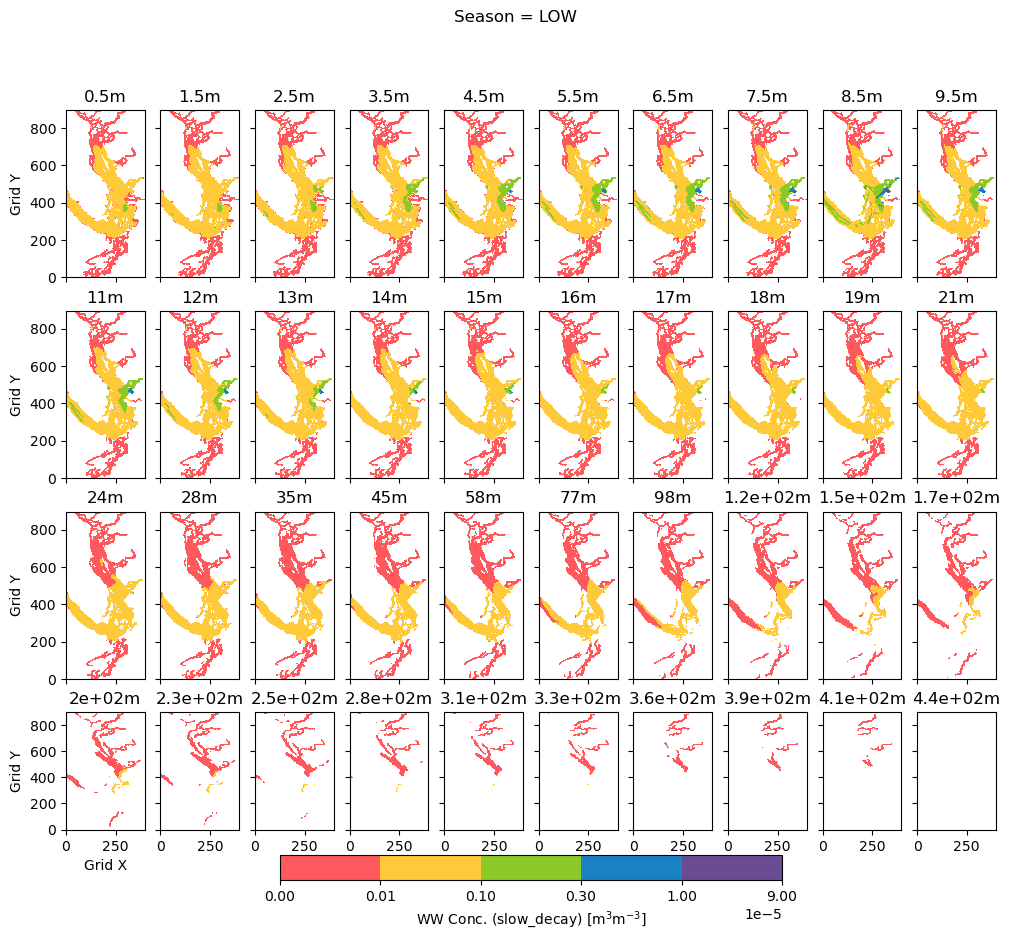

In [103]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12, 10), sharey=True, sharex=True)
fig.suptitle('Season = LOW')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, 'LOW', ax1[y,x], 'slow_decay', False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.2g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. ({}) '.format(vars[1]) + r'[m$^3$m$^{-3}$]'), location='bottom')

In [104]:
ww_high_seas = ww_seas_mean.sel(season='HIGH').slow_decay
ww_low_seas = ww_seas_mean.sel(season='LOW').slow_decay

In [105]:
ww_high_seas = ww_high_seas.stack(flat=['y', 'x']).to_numpy()
dmax = np.nanmax(ww_high_seas, axis=1)
dmin = np.nanmin(ww_high_seas, axis=1)
dquant = np.nanquantile(ww_high_seas, [0.25, 0.5, 0.75], axis=1)

iqr = dquant[2,:] - dquant[0,:]
lower_bound = dquant[0,:] - 1.5 * iqr
lower_bound[lower_bound < 0] = 0
upper_bound = dquant[2,:] + 1.5 * iqr

In [106]:
ww_low_seas = ww_low_seas.stack(flat=['y', 'x']).to_numpy()

In [107]:
outliers = ww_high_seas[ww_high_seas > upper_bound.reshape(-1, 1)]
outliers.shape

(649788,)

In [108]:
ww_high_seas[0,:].shape

(357404,)

In [109]:
ww_high_seas_max = np.nanmax(ww_high_seas)

In [110]:
def calc_percentages(ww_arr):
    water_bool = ~np.isnan(ww_arr)
    water_vals = ww_arr[water_bool]
    water_denom = len(water_vals)

    under_thresh_bool = water_vals < HC5_low
    HC5_low_bool = np.logical_and(water_vals >= HC5_low, water_vals < impact_urchins)
    impact_urchins_bool = np.logical_and(water_vals >= impact_urchins, water_vals < HC5)
    HC5_bool = np.logical_and(water_vals >= HC5, water_vals < impact_devel)
    impact_devel_bool = np.logical_and(water_vals >= impact_devel, water_vals < HC5_high)
    HC5_high_bool = np.logical_and(water_vals >= HC5_high, water_vals < HC50_low)

    bloc1 = len(water_vals[under_thresh_bool])/water_denom
    bloc2 = len(water_vals[HC5_low_bool])/water_denom
    bloc3 = len(water_vals[impact_urchins_bool])/water_denom
    bloc4 = len(water_vals[HC5_bool])/water_denom
    bloc5 = len(water_vals[impact_devel_bool])/water_denom
    bloc6 = len(water_vals[HC5_high_bool])/water_denom

    return [bloc1, bloc2, bloc3, bloc4, bloc5, bloc6]

Text(0.5, 1.0, 'Season=LOW')

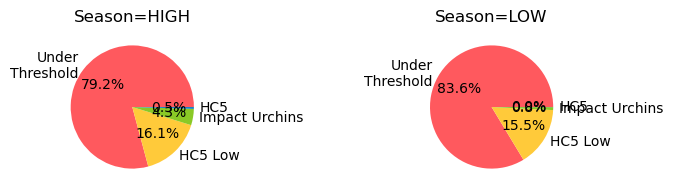

In [168]:
labels = 'Under\nThreshold', 'HC5 Low', 'Impact Urchins', 'HC5', 'Impact Development', 'HC5 High'
fig, ax1 = plt.subplots(1,2, figsize=(8.5,2))
explode = (0, 0, 0, 0)
ax1[0].pie(calc_percentages(ww_high_seas)[0:-2], labels=labels[0:-2], explode=explode, autopct='%1.1f%%', colors=custom_colors[0:-1])
ax1[0].set_title('Season=HIGH')

ax1[1].pie(calc_percentages(ww_low_seas)[0:-2], labels=labels[0:-2], explode=explode, autopct='%1.1f%%', colors=custom_colors[0:-1])
ax1[1].set_title('Season=LOW')

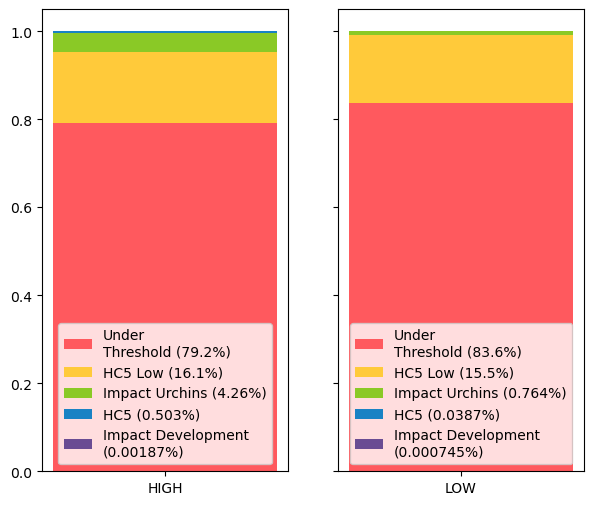

In [224]:
fig, ax1 = plt.subplots(1,2, figsize=(7,6), sharey=True)
# ax1[0].bar(['HIGH'], calc_percentages(ww_high_seas)[0:-2], labels=labels[0:-2], colors=custom_colors[0:-1])
data_high = calc_percentages(ww_high_seas)
ax1[0].bar(['HIGH'], data_high[0], label=labels[0]+' ({:.3g}%)'.format(data_high[0]*100), color=custom_colors[0], width=1)
ax1[0].bar(['HIGH'], data_high[1], bottom=data_high[0], label=labels[1]+' ({:.3g}%)'.format(data_high[1]*100), color=custom_colors[1], width=1)
ax1[0].bar(['HIGH'], data_high[2], bottom=data_high[0]+data_high[1], label=labels[2]+' ({:.3g}%)'.format(data_high[2]*100), color=custom_colors[2], width=1)
ax1[0].bar(['HIGH'], data_high[3], bottom=data_high[0]+data_high[1]+data_high[2], label=labels[3]+' ({:.3g}%)'.format(data_high[3]*100), color=custom_colors[3], width=1)
ax1[0].bar(['HIGH'], data_high[4], bottom=data_high[0]+data_high[1]+data_high[2]+data_high[3], label=labels[4]+'\n({:.3g}%)'.format(data_high[4]*100), color=custom_colors[4], width=1)
ax1[0].legend(loc='lower center')
ax1[0].set_ylim(0,1.05)

data_low = calc_percentages(ww_low_seas)
ax1[1].bar(['LOW'], data_low[0], label=labels[0]+' ({:.3g}%)'.format(data_low[0]*100), color=custom_colors[0], width=1)
ax1[1].bar(['LOW'], data_low[1], bottom=data_low[0], label=labels[1]+' ({:.3g}%)'.format(data_low[1]*100), color=custom_colors[1], width=1)
ax1[1].bar(['LOW'], data_low[2], bottom=data_low[0]+data_low[1], label=labels[2]+' ({:.3g}%)'.format(data_low[2]*100), color=custom_colors[2], width=1)
ax1[1].bar(['LOW'], data_low[3], bottom=data_low[0]+data_low[1]+data_low[2], label=labels[3]+' ({:.3g}%)'.format(data_low[3]*100), color=custom_colors[3], width=1)
ax1[1].bar(['LOW'], data_low[4], bottom=data_low[0]+data_low[1]+data_low[2]+data_low[3], label=labels[4]+'\n({:.3g}%)'.format(data_low[4]*100), color=custom_colors[4], width=1)
ax1[1].legend(loc='lower center')

In [112]:
# water_bool = ~np.isnan(ww_high_seas)
# water_vals = ww_high_seas[water_bool]
# water_denom = len(water_vals)

# under_thresh_bool = water_vals < HC5_low
# HC5_low_bool = np.logical_and(water_vals >= HC5_low, water_vals < impact_urchins)
# impact_urchins_bool = np.logical_and(water_vals >= impact_urchins, water_vals < HC5)
# HC5_bool = np.logical_and(water_vals >= HC5, water_vals < impact_devel)
# impact_devel_bool = np.logical_and(water_vals >= impact_devel, water_vals < HC5_high)
# HC5_high_bool = np.logical_and(water_vals >= HC5_high, water_vals < HC50_low)

# len(water_vals[under_thresh_bool])/water_denom
# len(water_vals[HC5_low_bool])/water_denom
# len(water_vals[impact_urchins_bool])/water_denom
# len(water_vals[HC5_bool])/water_denom
# len(water_vals[impact_devel_bool])/water_denom
# len(water_vals[HC5_high_bool])/water_denom

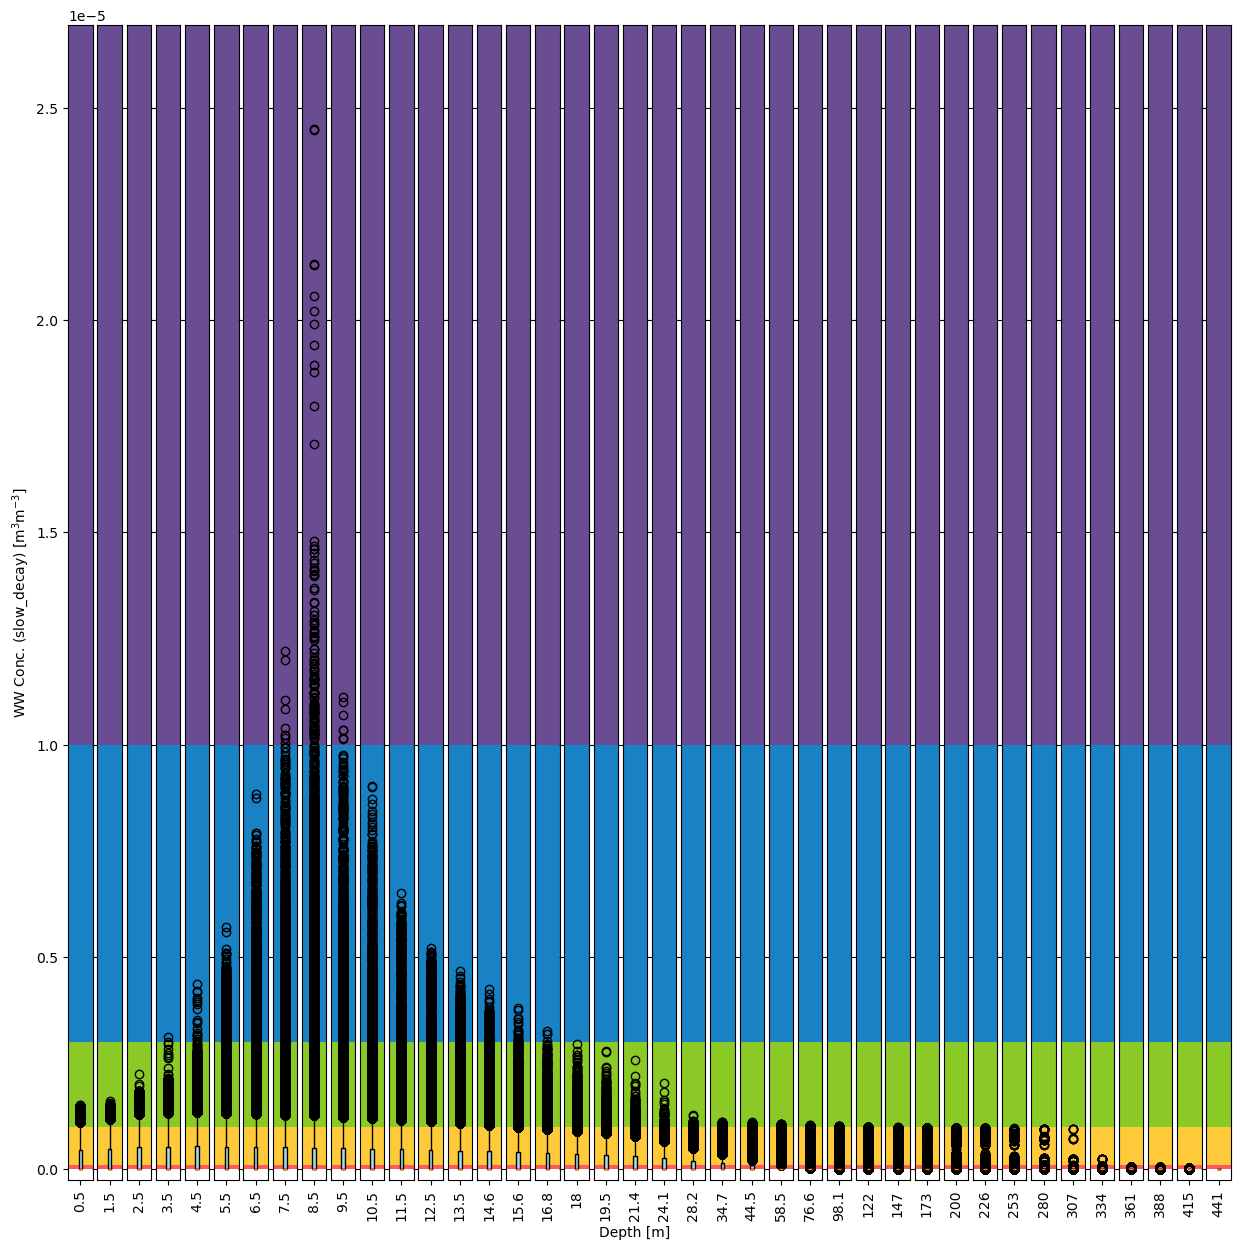

In [221]:
fig, ax = plt.subplots(1,40, figsize=(15, 15), sharey=True)  #TODO: change the boxes and whiskers to better fit my use case?

# i = 8
for i in np.arange(40):
    ub = upper_bound[i]
    ts = ww_high_seas[i,:]
    outliers = ts[ts > ub]

    boxplot_stats = [
        {
            'label': '{:.3g}'.format(float(ww_out.deptht[i])),
            'whislo': lower_bound[i],    # Bottom whisker (min non-outlier)
            'q1': dquant[0,i],      # First quartile (25th percentile)
            'med': dquant[1,i],     # Median (50th percentile)
            'q3': dquant[2,i],      # Third quartile (75th percentile)
            'whishi': upper_bound[i],    # Top whisker (max non-outlier)
            'fliers': outliers # Outliers
        }
    ]

    ax[i].bxp(boxplot_stats, showfliers=True, patch_artist=True, boxprops={'facecolor': 'lightblue'}, vert=True)

    ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5_high, facecolor=custom_colors[4]))
    ax[i].add_patch(plt.Rectangle((0.5, 0), 1, impact_devel, facecolor=custom_colors[3]))
    ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5, facecolor=custom_colors[2]))
    ax[i].add_patch(plt.Rectangle((0.5, 0), 1, impact_urchins, facecolor=custom_colors[1]))
    ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5_low, facecolor=custom_colors[0]))

    ax[i].set_ylim([-.25e-6, ww_high_seas_max*1.1])
    ax[i].tick_params(axis='x', labelrotation=90)
    

# Add labels and title
# fig.set_title('Manually Computed Box Plot')
ax[0].set_ylabel('WW Conc. ({}) '.format('slow_decay') + r'[m$^3$m$^{-3}$]')
# ax.set_xticks(range(1, 41))
# ax.set_xticklabels(['Custom Data'])
ax[19].set_xlabel('Depth [m]')

# [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high]
plt.show()

In [114]:
# fig, ax = plt.subplots(20,2, figsize=(15, 7), sharex=True)

# # i = 8
# for i in np.arange(40):
#     ub = upper_bound[i]
#     ts = ww_high_seas[i,:]
#     outliers = ts[ts > ub]

#     boxplot_stats = [
#         {
#             'label': '{:.2g}'.format(float(ww_out.deptht[i])),
#             'whislo': lower_bound[i],    # Bottom whisker (min non-outlier)
#             'q1': dquant[0,i],      # First quartile (25th percentile)
#             'med': dquant[1,i],     # Median (50th percentile)
#             'q3': dquant[2,i],      # Third quartile (75th percentile)
#             'whishi': upper_bound[i],    # Top whisker (max non-outlier)
#             'fliers': outliers # Outliers
#         }
#     ]
#     # print(int(i-i*np.floor(i/20)))
#     # print(int(np.floor(i/20)))

#     y = int(np.floor(i/20))
#     x = i - y*20

#     ax[x,y].bxp(boxplot_stats, showfliers=True, patch_artist=True, boxprops={'facecolor': 'lightblue'}, vert=False)

# # Add labels and title
# # fig.set_title('Manually Computed Box Plot')
# ax[9,0].set_ylabel('Depth [m]')
# # ax.set_xticks(range(1, 41))
# # ax.set_xticklabels(['Custom Data'])
# plt.show()

In [115]:
# test_1dep = ww_high_seas.isel(deptht=5).stack(flat=['y', 'x']).to_numpy()
# test_1dep = test_1dep[~np.isnan(test_1dep)]

# plt.boxplot(test_1dep)
# plt.show()

## Statistics

In [116]:
# fig, ax = plt.subplots(1,3, figsize=(15,5))
# fig.suptitle('{} 2016-2023'.format('Mean'))

# param_titles = ['Salinity', 'Temperature', 'pH']
# param_units = ['Salinity [g/kg]', 'Temperature [degC]', 'pH']

# for i in range(3):
#     boxplot = ax[i].boxplot(list_of_params[i], patch_artist=True)

#     ax[i].set_title(param_titles[i])
#     ax[i].set_ylabel(param_units[i])
#     ax[i].set_xticks(range(1, n_clusters + 1))
#     ax[i].set_xticklabels([f'Cluster {j}' for j in range(0, n_clusters)], rotation=45)

#     for box, color in zip(boxplot['boxes'], cluster_colors):
#         box.set_facecolor(color)

In [117]:
## box and whisker plot or violin plot for different depths, with lines for the limits of interest
## do one with each depth box first, then look into grouping them together at the bottom maybe?
## this should be done with the daily data, as I think the seasonal means will be better for visualization but the stats are quoteable
# plt.boxplot()

## Plot Input Data

#### Defns

In [118]:
matter_color = mcolors.to_hex(cm.matter(0.75))
haline_color = mcolors.to_hex(cm.haline(0.15))
thermal_color = mcolors.to_hex(cm.thermal(0.80))

### Plot: show the input data
Panel A: sum of all washwater volume over the domain
Panel B: histogram of individual washwater inputs
Panel C: histogram of temperature inputs
Panel D: histogram of salinity inputs

In [119]:
# fname = 'washwater_in'
# writervideo = animation.FFMpegWriter(fps=10)
# depth = 0 
# cmap = cm.matter
# cmap.set_bad('lightgray')
# cmap.set_under('gray')

# fig, ax = plt.subplots(1,1, figsize = (5, 9))
# washwater = np.ma.masked_array(np.nan_to_num(ww_in.washwater.isel(time=0, depth=depth)), mask=tmask[0])
# colours = ax.pcolormesh(washwater, cmap=cmap, vmax=150, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax, label=r'Washwater [m$^3$]')
# viz_tools.set_aspect(ax);

# def newframe(frame_num):
#     washwater = np.ma.masked_array(np.nan_to_num(ww_in.washwater.isel(time=frame_num, depth=depth)), mask=tmask[depth])
#     colours.set_array(washwater.ravel())
#     dtime = pd.to_datetime(ww_in['time'].values[frame_num])
#     ax.set_title(str(dtime.date()))
#     viz_tools.set_aspect(ax);

# ani = FuncAnimation(fig, newframe, frames=len(ww_in['time']), repeat=False)
# ani.save('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/animations/{}.mp4'.format(fname), writer=writervideo)

In [120]:
# fname = 'washwater_in_depth8.5'
# writervideo = animation.FFMpegWriter(fps=10)
# depth = 0
# cmap = cm.matter
# cmap.set_bad('lightgray')
# cmap.set_under('gray')

# fig, ax = plt.subplots(1,1, figsize = (5, 9))
# washwater = np.ma.masked_array(np.nan_to_num(ww_in.washwater.isel(time=0, depth=depth)), mask=tmask[8])
# colours = ax.pcolormesh(washwater, cmap=cmap, vmax=150, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax, label=r'Washwater [m$^3$]')
# viz_tools.set_aspect(ax);

# def newframe(frame_num):
#     washwater = np.ma.masked_array(np.nan_to_num(ww_in.washwater.isel(time=frame_num, depth=depth)), mask=tmask[8])
#     colours.set_array(washwater.ravel())
#     dtime = pd.to_datetime(ww_in['time'].values[frame_num])
#     ax.set_title(str(dtime.date()))
#     viz_tools.set_aspect(ax);

# ani = FuncAnimation(fig, newframe, frames=len(ww_in['time']), repeat=False)
# ani.save('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/animations/{}.mp4'.format(fname), writer=writervideo)

In [121]:
ww_in_sum = ww_in.washwater.sum(dim='time')

In [122]:
washwater_flat = ww_in.washwater.values.flatten()
temp_out_flat = ww_in.temp_out.values.flatten()
sal_out_flat = ww_in.sal_out.values.flatten()

washwater_flat = washwater_flat[~np.isnan(washwater_flat)]
temp_out_flat = temp_out_flat[~np.isnan(temp_out_flat)]
sal_out_flat = sal_out_flat[~np.isnan(sal_out_flat)]

In [123]:
# cmap = cm.matter
# cmap.set_bad('lightgray')
# cmap.set_under('gray')

# fig, ax = plt.subplots(1,1, figsize = (5, 9))
# washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum.isel(depth=0)), mask=tmask[8])
# colours = ax.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax, label=r'Washwater [m$^3$]')
# US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
# patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='-.')
# ax.add_patch(patch)

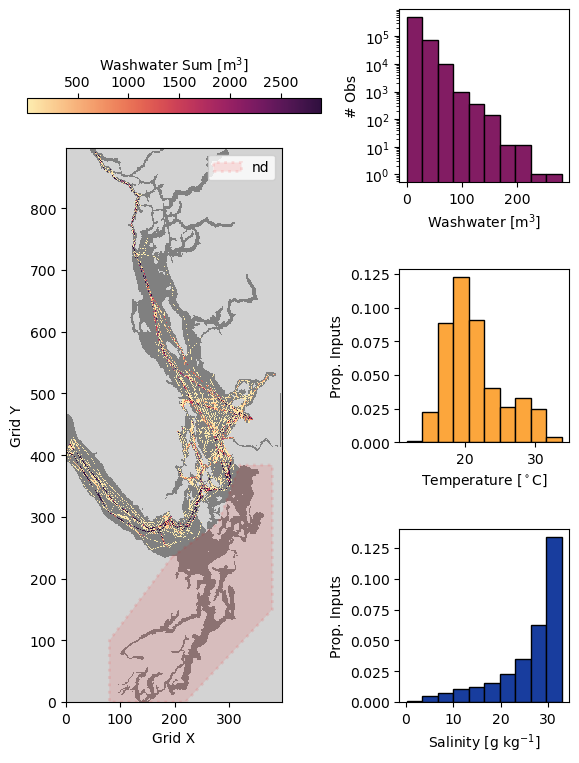

In [124]:
cmap = cm.matter
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig = plt.figure(figsize = (7, 9))
grid = plt.GridSpec(3,5, wspace=1.7, hspace=0.5)
ax1 = plt.subplot(grid[0:,0:3])
ax2 = plt.subplot(grid[0,3:])
ax3 = plt.subplot(grid[1,3:])
ax4 = plt.subplot(grid[2,3:])

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax1.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
cb = fig.colorbar(colours, ax=ax1, label=r'Washwater Sum [m$^3$]', location='top')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
ax1.add_patch(patch)
ax1.set_ylabel('Grid Y')
ax1.set_xlabel('Grid X')
viz_tools.set_aspect(ax1);

ax2.hist(washwater_flat, 10, density=False, log=True, color=matter_color, edgecolor='k')
ax2.set_xlabel(r'Washwater [m$^3$]')
ax2.set_ylabel('# Obs')

ax3.hist(temp_out_flat, 10, density=True, log=False, color=thermal_color, edgecolor='k')
ax3.set_xlabel(r'Temperature [$^\circ$C]')
ax3.set_ylabel('Prop. Inputs')

ax4.hist(sal_out_flat, 10, density=True, log=False, color=haline_color, edgecolor='k')
ax4.set_xlabel(r'Salinity [g kg$^{-1}$]')
ax4.set_ylabel('Prop. Inputs')

ax1.legend()

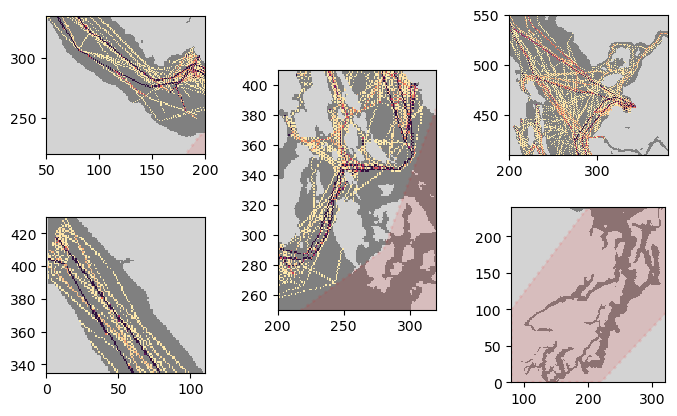

In [125]:
cmap = cm.matter
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig = plt.figure(figsize = (11, 5))
grid = plt.GridSpec(4,8, wspace=1.7, hspace=0.5)
ax1 = plt.subplot(grid[0:2,0:2])
ax2 = plt.subplot(grid[2:4,0:2])
ax3 = plt.subplot(grid[0:4:,2:4])
ax4 = plt.subplot(grid[0:2:,4:6])
ax5 = plt.subplot(grid[2:4:,4:6])

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax1.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax1, label=r'Washwater Sum [m$^3$]', location='left')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax1.add_patch(patch)
ax1.set_xlim([50,200])
ax1.set_ylim([220,335])
viz_tools.set_aspect(ax1);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax2.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax2, label=r'Washwater Sum [m$^3$]', location='left')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax2.add_patch(patch)
ax2.set_xlim([0,110])
ax2.set_ylim([335,430])
viz_tools.set_aspect(ax2);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax3.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax3, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax3.add_patch(patch)
ax3.set_xlim([200,320])
ax3.set_ylim([250,410])
viz_tools.set_aspect(ax3);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax4.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax4, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax4.add_patch(patch)
ax4.set_xlim([200,380])
ax4.set_ylim([410,550])
viz_tools.set_aspect(ax4);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax5.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax5, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax5.add_patch(patch)
ax5.set_xlim([80,320])
ax5.set_ylim([0,240])
viz_tools.set_aspect(ax5);

## SRKW Habitat

In [126]:
crit_hab = gpd.read_file('crit_hab.gdb', layer='DFO_SARA_CH_EDH_EN')

In [127]:
orca = crit_hab['COMMON_E'] == 'Killer Whale'
crit_hab[orca]

,COMMON_E,POP_E,COMMON_F,POP_F,SCIENTIFIC,TAXON_E,ECO_TYPE_E,Waterbody,SARASTAT_E,CHSTATUS_E,COMMENT_E,LEAD_REG_E,SUP_REG_E,PROFILE_E,Area_Km2,Shape_Length,Shape_Area,geometry
864,Killer Whale,Northeast Pacific Northern Resident,Épaulard,résidente du nord du Pacifique Nord-Est,Orcinus orca,Mammals,Marine,Pacific Ocean/Océan Pacifique,Threatened,Final,None,Pacific,None,https://species-registry.canada.ca/index-en.ht...,7319.681360,1.924220e+06,1.774748e+10,"MULTIPOLYGON (((-13985503.47 6274700.411, -139..."
865,Killer Whale,Northeast Pacific Southern Resident,Épaulard,résidente du sud du Pacifique Nord-Est,Orcinus orca,Mammals,Marine,Pacific Ocean/Océan Pacifique,Endangered,Final,None,Pacific,None,https://species-registry.canada.ca/index-en.ht...,7496.738906,1.913499e+06,1.712860e+10,"MULTIPOLYGON (((-13985503.47 6274700.411, -139..."


In [128]:
poly1 = crit_hab.iloc[864]['geometry']
poly2 = crit_hab.iloc[865]['geometry']

In [129]:
poly2.type

/tmp/ipykernel_3245340/2290924752.py:1: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  poly2.type


'MultiPolygon'

In [130]:
ww_high_seas

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)